# r/gaming Centrality Analysis

This notebook builds a directed user reply network from the MADOC r/gaming dataset
and computes centrality measures to identify toxic/influential users. IT USES 'centrality_comments_2020,parquet' AS A DATA SOURCE, ensure this is in /data to run cells properly.

**Question:** Which gaming communities on r/gaming exhibit the most negative sentiment,
and what roles do toxic users play within and between those communities?

**This notebook covers:**
1. Load & filter data
2. Build directed reply network
3. Compute centrality measures (Degree, In-degree, Betweenness, PageRank)
4. Attach user toxicity/sentiment as node attributes
5. Visualise results
6. Export results for other team members

## 0. Install & Import Libraries

In [ ]:
#run this cell once if you don't have these installed
#!pip install networkx pandas matplotlib seaborn pyarrow

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#make plots look nicer
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Data

In [ ]:
df = pd.read_parquet('data/centrality_comments_2020.parquet')


In [ ]:
print(len(df))
print(len(fr))

3374714
2910933


In [7]:
#quick check on the key columns to use
print('Toxicity score distribution:')
print(df['toxicity_toxigen'].describe())
print('\nVADER sentiment distribution:')
print(df['sentiment_vader'].describe())

Toxicity score distribution:
count    2.910933e+06
mean     9.556367e-02
std      2.595854e-01
min      5.528495e-04
25%      7.944231e-04
50%      1.291613e-03
75%      5.971506e-03
max      9.924639e-01
Name: toxicity_toxigen, dtype: float64

VADER sentiment distribution:
count    2.910933e+06
mean     1.220758e-01
std      4.315720e-01
min     -9.999000e-01
25%      0.000000e+00
50%      0.000000e+00
75%      4.434000e-01
max      1.000000e+00
Name: sentiment_vader, dtype: float64


## 2. Build User-Level Node Attributes

Before building the graph, aggregate each user's average toxicity
and sentiment scores. These will be attached to nodes in the network.

In [8]:
#aggregate per-user stats from ALL their comments
user_stats = df.groupby('user_id').agg(
    avg_toxicity=('toxicity_toxigen', 'mean'),
    avg_sentiment=('sentiment_vader', 'mean'),
    comment_count=('post_id', 'count')
).reset_index()

#label users as toxic if their average toxicity score is above 0.3
#this threshold can be adjusted - 0.3 lowered from 0.5 due to skewed distribution (users surpisingly non-toxic)
user_stats['is_toxic'] = user_stats['avg_toxicity'] > 0.3

print(f'Total users: {len(user_stats)}')
print(f'Toxic users (avg toxicity > 0.3): {user_stats["is_toxic"].sum()}')
print(f'Toxic user percentage: {user_stats["is_toxic"].mean()*100:.1f}%')
user_stats.head()

Total users: 819324
Toxic users (avg toxicity > 0.3): 84451
Toxic user percentage: 10.3%


,user_id,avg_toxicity,avg_sentiment,comment_count,is_toxic
0,0000064c-56d3-5a80-ad9d-328d349f0124,0.357157,-0.401900,1,True
1,00000b1b-52d4-5d2d-b9a5-bfc865308562,0.908678,-0.510500,2,True
2,000032a4-d786-53fd-8f81-23a84123ed8c,0.245620,0.164425,4,False
3,00003e49-03f4-556e-90e0-78e6723868f6,0.000752,0.536750,2,False
4,00004efc-afd8-525e-b238-e916efa088d5,0.003337,-0.771700,1,False


## 3. Build Directed Reply Network

- **Nodes** = users (user_id)
- **Edges** = directed reply relationships (user_id replied to parent_user_id)
- **Edge weight** = number of times user A replied to user B
- **Node attributes** = avg_toxicity, avg_sentiment, comment_count

In [9]:
#build edge list: count how many times each user replied to each other user
edge_list = df.groupby(['user_id', 'parent_user_id']).size().reset_index(name='weight')

print(f'Total edges (unique reply pairs): {len(edge_list)}')
print(f'Max reply weight (most frequent reply pair): {edge_list["weight"].max()}')
edge_list.head()

Total edges (unique reply pairs): 2872306
Max reply weight (most frequent reply pair): 78


,user_id,parent_user_id,weight
0,0000064c-56d3-5a80-ad9d-328d349f0124,2db9e0bc-dd54-526a-a0dc-9c4349999b4e,1
1,00000b1b-52d4-5d2d-b9a5-bfc865308562,5e2a4e4f-de44-5eee-8e87-49ca92df1c7e,1
2,00000b1b-52d4-5d2d-b9a5-bfc865308562,cac233d2-d248-575b-81eb-2eb5b85aed16,1
3,000032a4-d786-53fd-8f81-23a84123ed8c,1ce905a4-1299-5518-8dde-f6ccae876cb9,1
4,000032a4-d786-53fd-8f81-23a84123ed8c,30549f93-3c99-5747-add1-a68bbe46690c,1


In [ ]:
#create directed graph
G = nx.DiGraph()

#add weighted edges
for _, row in edge_list.iterrows():
    G.add_edge(row['user_id'], row['parent_user_id'], weight=row['weight'])

#attach node attributes (toxicity, sentiment, activity)
user_attr = user_stats.set_index('user_id').to_dict('index')
nx.set_node_attributes(G, user_attr)

print(f'Graph built successfully.')
print(f'Nodes (users): {G.number_of_nodes()}')
print(f'Edges (reply relationships): {G.number_of_edges()}')
print(f'Is directed: {G.is_directed()}')

Graph built successfully.
Nodes (users): 890089
Edges (reply relationships): 2872306
Is directed: True


In [ ]:
#basic network statistics
print('=== Network Summary Statistics ===')
print(f'Number of nodes: {G.number_of_nodes()}')
print(f'Number of edges: {G.number_of_edges()}')
print(f'Network density: {nx.density(G):.6f}')

#largest weakly connected component
largest_wcc = max(nx.weakly_connected_components(G), key=len)
print(f'Largest connected component size: {len(largest_wcc)} nodes')
print(f'Percentage of nodes in largest component: {len(largest_wcc)/G.number_of_nodes()*100:.1f}%')

=== Network Summary Statistics ===
Number of nodes: 890089
Number of edges: 2872306
Network density: 0.000004
Largest connected component size: 886277 nodes
Percentage of nodes in largest component: 99.6%


## 4. Compute Centrality Measures

Compute four centrality measures, each revealing a different aspect of user role:

| Measure | What it reveals |
|---|---|
| Degree Centrality | Overall activity - who replies/gets replied to most |
| In-degree Centrality | Who attracts the most replies (provocative users) |
| Betweenness Centrality | Who bridges communities - potential toxicity spreaders |
| PageRank | Who is influential based on quality of connections |

In [10]:
print('Computing centrality measures... (betweenness may take a few minutes on large graphs)')

#degree centrality - proportion of nodes each node is connected to
degree_centrality = nx.degree_centrality(G)

#in-degree centrality - how many users reply TO this user
in_degree_centrality = nx.in_degree_centrality(G)

#out-degree centrality - how many users this user replies TO
out_degree_centrality = nx.out_degree_centrality(G)

Computing centrality measures... (betweenness may take a few minutes on large graphs)


NameError: name 'G' is not defined

In [9]:
#PageRank - influential nodes based on who links to them
pagerank = nx.pagerank(G, weight='weight')

In [10]:
print('Computing betweenness (sampled)...')
betweenness_centrality = nx.betweenness_centrality(
    G, weight='weight', k=200, normalized=True, seed=42
)
print('Betweenness done!')

Computing betweenness (sampled)...
Betweenness done!


In [ ]:
#combine all centrality measures into one dataframe
centrality_df = pd.DataFrame({
    'user_id': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'in_degree_centrality': [in_degree_centrality[n] for n in degree_centrality.keys()],
    'out_degree_centrality': [out_degree_centrality[n] for n in degree_centrality.keys()],
    #'betweenness_centrality': [betweenness_centrality[n] for n in degree_centrality.keys()],
    'pagerank': [pagerank[n] for n in degree_centrality.keys()]
})

#merge with user stats (toxicity, sentiment)
centrality_df = centrality_df.merge(user_stats, on='user_id', how='left')

print(f'Centrality dataframe shape: {centrality_df.shape}')
centrality_df.head()

Centrality dataframe shape: (890089, 10)


,user_id,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,pagerank,avg_toxicity,avg_sentiment,comment_count,is_toxic
0,0000064c-56d3-5a80-ad9d-328d349f0124,0.000001,0.000000,0.000001,0.000000e+00,5.260921e-07,0.357157,-0.4019,1.0,True
1,2db9e0bc-dd54-526a-a0dc-9c4349999b4e,0.000283,0.000279,0.000004,1.569442e-08,2.685077e-05,0.002905,0.0193,4.0,False
2,00000b1b-52d4-5d2d-b9a5-bfc865308562,0.000002,0.000000,0.000002,0.000000e+00,5.260921e-07,0.908678,-0.5105,2.0,True
3,5e2a4e4f-de44-5eee-8e87-49ca92df1c7e,0.000034,0.000029,0.000004,2.687134e-07,1.795966e-06,0.002851,0.4537,4.0,False
4,cac233d2-d248-575b-81eb-2eb5b85aed16,0.000263,0.000262,0.000001,2.564230e-08,3.155541e-05,0.000943,0.4019,1.0,False


## 5. Top Users by Centrality

In [12]:
#summary stats for all centrality measures
print('=== Centrality Measure Summary ===')
centrality_df[['degree_centrality', 'in_degree_centrality', 
               'betweenness_centrality', 'pagerank']].describe().round(6)

=== Centrality Measure Summary ===


,degree_centrality,in_degree_centrality,betweenness_centrality,pagerank
count,890089.000000,890089.000000,890089.000000,890089.000000
mean,0.000007,0.000004,0.000000,0.000001
std,0.000059,0.000057,0.000016,0.000015
min,0.000001,0.000000,0.000000,0.000001
25%,0.000001,0.000000,0.000000,0.000001
50%,0.000001,0.000000,0.000000,0.000001
75%,0.000003,0.000000,0.000000,0.000001
max,0.025897,0.025897,0.005052,0.006372


In [ ]:
#top 10 users by each centrality measure
top_n = 10
for measure in ['degree_centrality', 'in_degree_centrality', 'betweenness_centrality', 'pagerank']:
    print(f'\n=== Top {top_n} by {measure} ===')
    top = centrality_df.nlargest(top_n, measure)[[
        'user_id', measure, 'avg_toxicity', 'avg_sentiment', 'comment_count', 'is_toxic'
    ]]
    print(top.to_string(index=False))


=== Top 10 by degree_centrality ===
                             user_id  degree_centrality  avg_toxicity  avg_sentiment  comment_count is_toxic
aabda857-1e72-5c2c-8e32-7ab39e98b45e           0.025897           NaN            NaN            NaN      NaN
c8eb554f-188d-5218-aa2b-9033a60e7dac           0.016162           NaN            NaN            NaN      NaN
da58097b-b82d-59f1-851d-da13b4e35b58           0.008612           NaN            NaN            NaN      NaN
aea51f21-975d-5f6a-bb54-01df0d0f7244           0.006579      0.044031       0.000000            2.0    False
a2097026-d7c3-5256-b3d3-a5f602492420           0.006430      0.263935       0.091833            3.0    False
227bb442-b748-5ac2-a522-0d830545ce37           0.005247      0.000971       0.585900            1.0    False
0e7b1f1a-2317-5f1f-8450-a9483d31fb0a           0.005069      0.001228       0.000000            1.0    False
68744250-1d85-5d34-a41c-eabfc3f9c3be           0.004919      0.035722       0.231879       

In [ ]:
#check how many centrality users have missing toxicity or sentiment
nan_count = centrality_df[centrality_df['avg_toxicity'].isna()].shape[0]
print(f'Users with NaN attributes: {nan_count}')
print(f'Percentage of total: {nan_count/len(centrality_df)*100:.1f}%')

#filter to only users with full toxicity and sentiment data
centrality_df_known = centrality_df.dropna(subset=['avg_toxicity', 'avg_sentiment'])
print(f'Users with full data: {len(centrality_df_known)}')

#key question: do high centrality users tend to be more toxic?
print('=== Average toxicity by centrality quartile (PageRank) ===')
centrality_df_known['pagerank_quartile'] = pd.qcut(
    centrality_df_known['pagerank'], q=4, labels=False, duplicates='drop'
)
quartile_labels = ['Low', 'Mid-Low', 'Mid-High', 'High']
centrality_df_known['pagerank_quartile'] = centrality_df_known['pagerank_quartile'].map(
    lambda x: quartile_labels[int(x)] if pd.notna(x) else np.nan
)
toxicity_by_quartile = centrality_df_known.groupby('pagerank_quartile')['avg_toxicity'].mean()
print(toxicity_by_quartile)

print('\n=== Average toxicity by centrality quartile (Betweenness) ===')
centrality_df_known['betweenness_quartile'] = pd.qcut(
    centrality_df_known['betweenness_centrality'], q=4,
    labels=False,
    duplicates='drop'
)
centrality_df_known['betweenness_quartile'] = centrality_df_known['betweenness_quartile'].map(
    lambda x: quartile_labels[int(x)] if pd.notna(x) else np.nan
)
toxicity_by_betweenness = centrality_df_known.groupby('betweenness_quartile')['avg_toxicity'].mean()
print(toxicity_by_betweenness)

Users with NaN attributes: 70765
Percentage of total: 8.0%
Users with full data: 819324
=== Average toxicity by centrality quartile (PageRank) ===
pagerank_quartile
Low    0.090345
Name: avg_toxicity, dtype: float64

=== Average toxicity by centrality quartile (Betweenness) ===
betweenness_quartile
Low    0.090345
Name: avg_toxicity, dtype: float64


In [ ]:
#confirm quartile labels are only calculated for users with full toxicity/sentiment data
quartile_counts = centrality_df_known[['pagerank_quartile', 'betweenness_quartile']].apply(pd.Series.value_counts)
print('Quartile counts for users with full data:')
print(quartile_counts)
print(f"Total users used in quartile analysis: {len(centrality_df_known)}")

Quartile counts for users with full data:
     pagerank_quartile  betweenness_quartile
Low             819324                819324
Total users used in quartile analysis: 819324


In [ ]:
#check how many top centrality users have NaN attributes
nan_count = centrality_df[centrality_df['avg_toxicity'].isna()].shape[0]
print(f'Users with NaN attributes: {nan_count}')
print(f'Percentage of total: {nan_count/len(centrality_df)*100:.1f}%')

#filter to only users we have full data for
centrality_df_known = centrality_df.dropna(subset=['avg_toxicity', 'avg_sentiment'])
print(f'Users with full data: {len(centrality_df_known)}')

Users with NaN attributes: 70765
Percentage of total: 8.0%
Users with full data: 819324


## 6. Visualisations

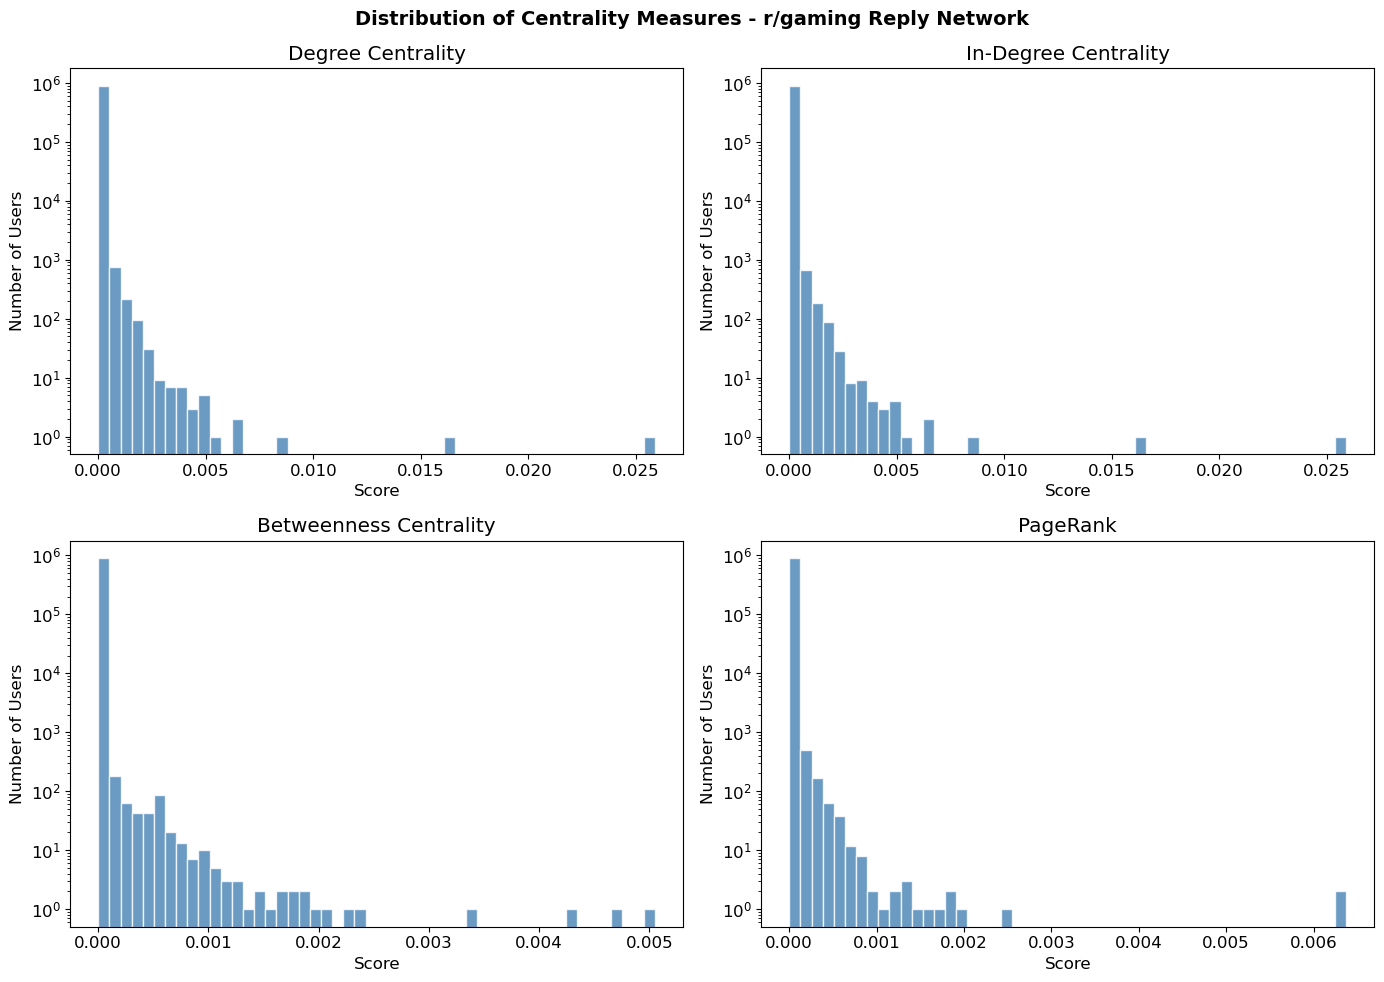

Saved: data/centrality_distributions.png


In [ ]:
#distribution of centrality measures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Centrality Measures - r/gaming Reply Network', fontsize=14, fontweight='bold')

measures = ['degree_centrality', 'in_degree_centrality', 'betweenness_centrality', 'pagerank']
titles = ['Degree Centrality', 'In-Degree Centrality', 'Betweenness Centrality', 'PageRank']

for ax, measure, title in zip(axes.flatten(), measures, titles):
    ax.hist(centrality_df[measure], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Users')
    ax.set_yscale('log')  #log scale because distributions are heavily skewed

plt.tight_layout()
plt.savefig('data/centrality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/centrality_distributions.png')

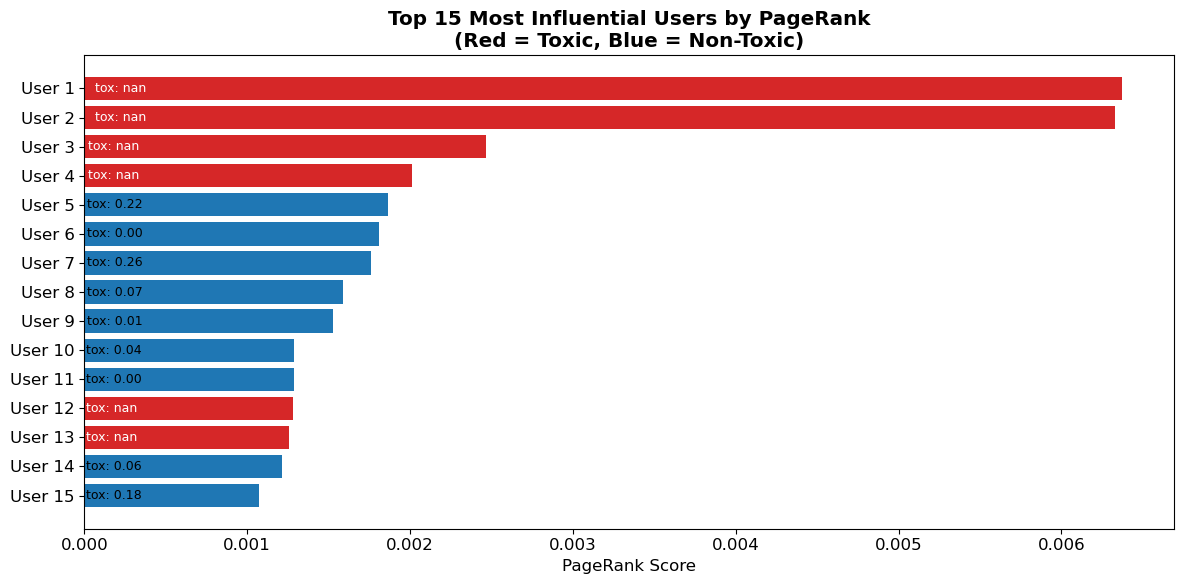

Saved: data/top15_pagerank.png


In [ ]:
#top 15 users by PageRank coloured by toxicity
top15_pr = centrality_df.nlargest(15, 'pagerank')

fig, ax = plt.subplots(figsize=(12, 6))
colours = ['#d62728' if t else '#1f77b4' for t in top15_pr['is_toxic']]
bars = ax.barh(range(len(top15_pr)), top15_pr['pagerank'], color=colours)
ax.set_yticks(range(len(top15_pr)))
ax.set_yticklabels([f'User {i+1}' for i in range(len(top15_pr))])  # anonymised labels
ax.set_xlabel('PageRank Score')
ax.set_title('Top 15 Most Influential Users by PageRank\n(Red = Toxic, Blue = Non-Toxic)', fontweight='bold')
ax.invert_yaxis()

#add toxicity score as text on bars
for i, (_, row) in enumerate(top15_pr.iterrows()):
    ax.text(row['pagerank'] * 0.01, i, f"tox: {row['avg_toxicity']:.2f}", 
            va='center', fontsize=9, color='white' if row['is_toxic'] else 'black')

plt.tight_layout()
plt.savefig('data/top15_pagerank.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/top15_pagerank.png')

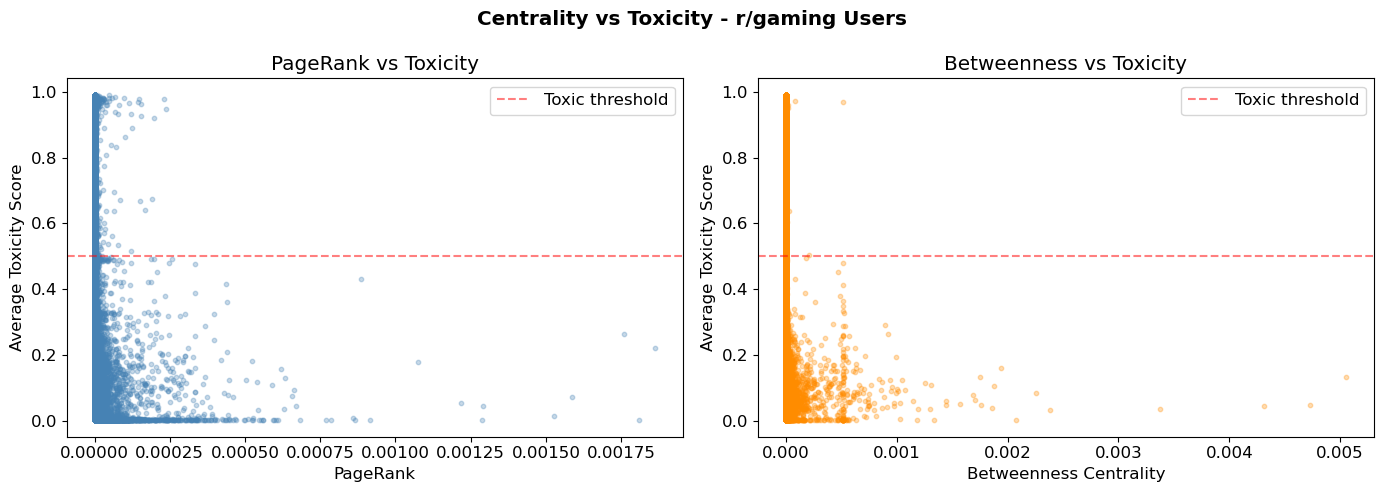

Saved: data/centrality_vs_toxicity.png


In [ ]:
#toxicity vs PageRank scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Centrality vs Toxicity - r/gaming Users', fontweight='bold')

#PageRank vs toxicity
axes[0].scatter(centrality_df['pagerank'], centrality_df['avg_toxicity'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('PageRank')
axes[0].set_ylabel('Average Toxicity Score')
axes[0].set_title('PageRank vs Toxicity')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Toxic threshold')
axes[0].legend()

#betweenness vs toxicity
axes[1].scatter(centrality_df['betweenness_centrality'], centrality_df['avg_toxicity'],
                alpha=0.3, s=10, color='darkorange')
axes[1].set_xlabel('Betweenness Centrality')
axes[1].set_ylabel('Average Toxicity Score')
axes[1].set_title('Betweenness vs Toxicity')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Toxic threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/centrality_vs_toxicity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/centrality_vs_toxicity.png')

In [ ]:
#quartile analysis
print('=== Average toxicity by PageRank quartile ===')

#filter to users above 25th percentile to avoid flat distribution from skew
pr_nonzero = centrality_df_known[
    centrality_df_known['pagerank'] > centrality_df_known['pagerank'].quantile(0.25)
].copy()

pr_nonzero['pagerank_quartile'] = pd.qcut(
    pr_nonzero['pagerank'], q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High'],
    duplicates='drop'
)
print(pr_nonzero.groupby('pagerank_quartile')['avg_toxicity'].mean())

print('\n=== Average toxicity by Betweenness quartile ===')
bt_nonzero = centrality_df_known[centrality_df_known['betweenness_centrality'] > 0].copy()
print(f'Users with non-zero betweenness: {len(bt_nonzero)}')

bt_nonzero['betweenness_quartile'] = pd.qcut(
    bt_nonzero['betweenness_centrality'], q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High'],
    duplicates='drop'
)
print(bt_nonzero.groupby('betweenness_quartile')['avg_toxicity'].mean())

print('\n=== Toxic vs Non-toxic user centrality comparison ===')
print(centrality_df_known.groupby('is_toxic')[['degree_centrality', 'in_degree_centrality',
                                                'betweenness_centrality', 'pagerank']].mean())

=== Average toxicity by PageRank quartile ===
pagerank_quartile
Low         0.087715
Mid-Low     0.087849
Mid-High    0.090235
High        0.087311
Name: avg_toxicity, dtype: float64

=== Average toxicity by Betweenness quartile ===
Users with non-zero betweenness: 34022
betweenness_quartile
Low         0.091539
Mid-Low     0.086772
Mid-High    0.084197
High        0.087114
Name: avg_toxicity, dtype: float64

=== Toxic vs Non-toxic user centrality comparison ===
          degree_centrality  in_degree_centrality  betweenness_centrality  \
is_toxic                                                                    
False              0.000006              0.000002            3.833236e-07   
True               0.000004              0.000002            8.346481e-08   

              pagerank  
is_toxic                
False     8.913505e-07  
True      7.664465e-07  


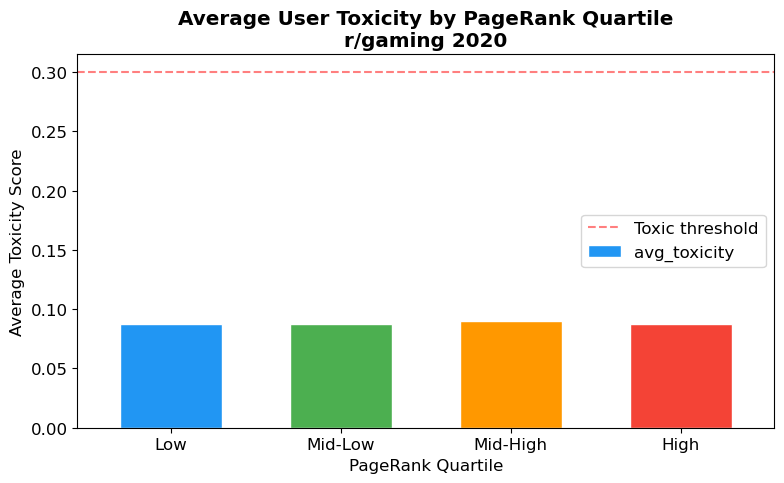

In [ ]:
#average toxicity by PageRank quartile (bar chart)
fig, ax = plt.subplots(figsize=(8, 5))

quartile_toxicity = pr_nonzero.groupby('pagerank_quartile')['avg_toxicity'].mean()
quartile_toxicity.plot(kind='bar', ax=ax, color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'], 
                       edgecolor='white', width=0.6)

ax.set_title('Average User Toxicity by PageRank Quartile\nr/gaming 2020', fontweight='bold')
ax.set_xlabel('PageRank Quartile')
ax.set_ylabel('Average Toxicity Score')
ax.set_xticklabels(['Low', 'Mid-Low', 'Mid-High', 'High'], rotation=0)
ax.axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Toxic threshold')
ax.legend()

plt.tight_layout()
plt.savefig('data/toxicity_by_pagerank_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

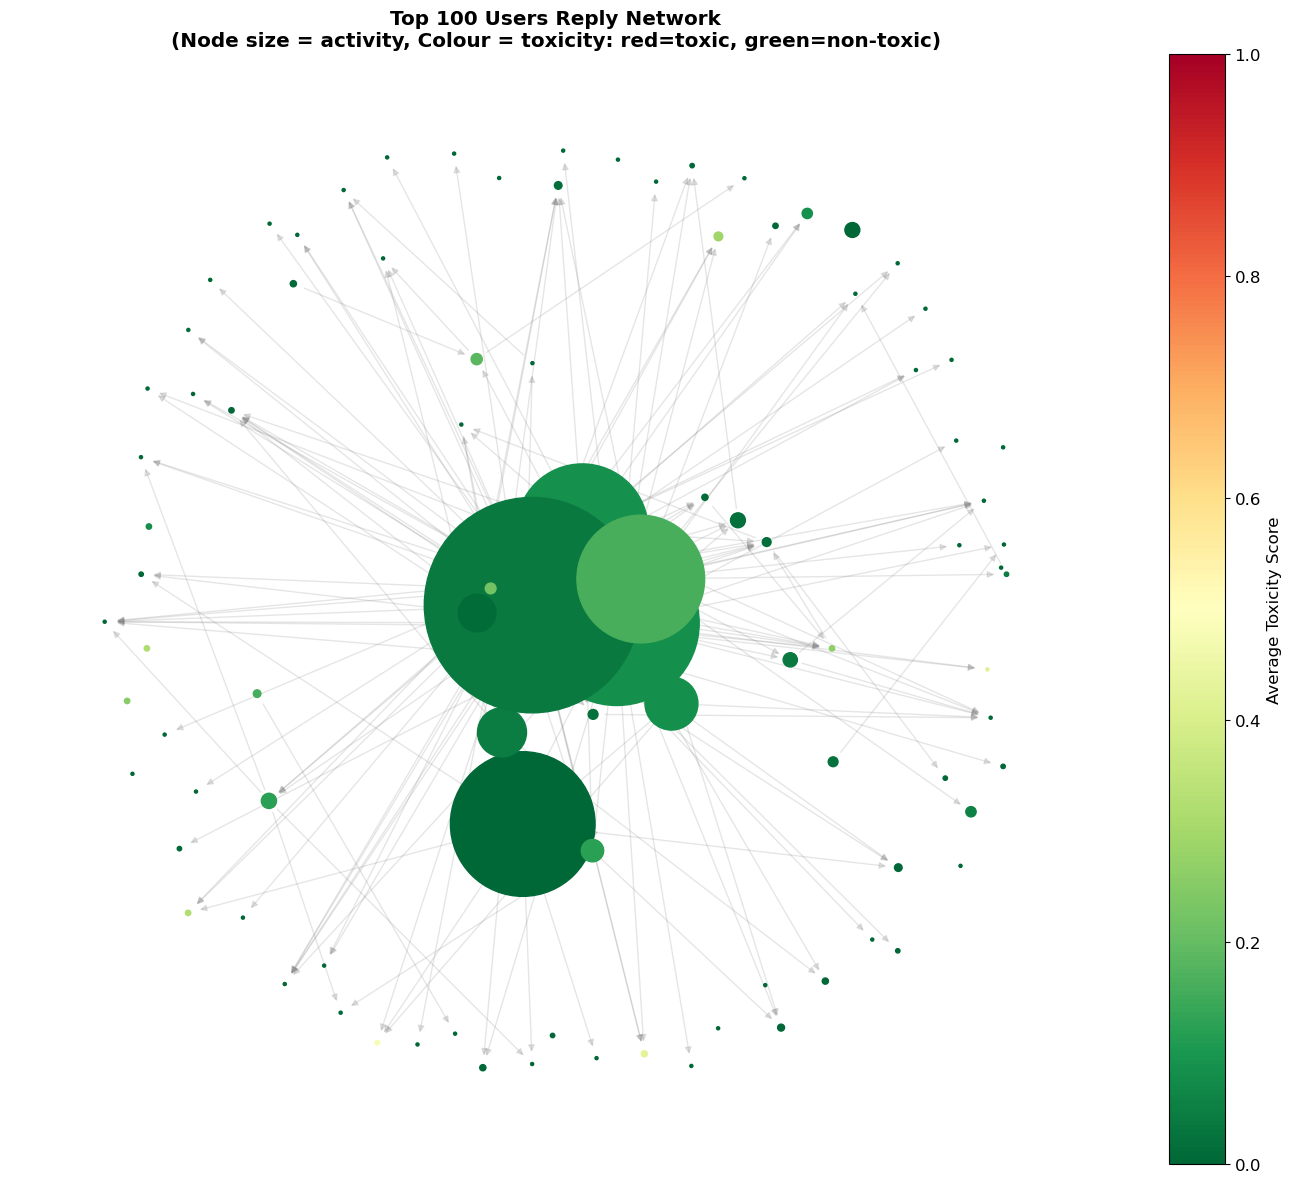

Saved: data/network_top100.png


In [ ]:
#network visualisation (subgraph of top users)
top100_nodes = centrality_df.nlargest(100, 'degree_centrality')['user_id'].tolist()
subgraph = G.subgraph(top100_nodes)

fig, ax = plt.subplots(figsize=(14, 12))

#layout
pos = nx.spring_layout(subgraph, seed=42, k=0.5)

#node colours based on toxicity
node_toxicity = [G.nodes[n].get('avg_toxicity', 0) for n in subgraph.nodes()]
node_sizes = [G.nodes[n].get('comment_count', 1) * 5 for n in subgraph.nodes()]

#draw edges
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, arrows=True, 
                       arrowsize=10, edge_color='grey', ax=ax)

#draw nodes coloured by toxicity
nodes = nx.draw_networkx_nodes(subgraph, pos, node_color=node_toxicity,
                                node_size=node_sizes, cmap=plt.cm.RdYlGn_r,
                                vmin=0, vmax=1, ax=ax)

#colourbar
plt.colorbar(nodes, ax=ax, label='Average Toxicity Score')

ax.set_title('Top 100 Users Reply Network\n(Node size = activity, Colour = toxicity: red=toxic, green=non-toxic)',
             fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('data/network_top100.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/network_top100.png')

Users with community labels: 879627
Number of communities: 47
Users with both centrality and community data: 810816
Communities represented: 47
=== Community Summary (sorted by avg toxicity) ===
 community_id  user_count  avg_toxicity  avg_sentiment  avg_pagerank  avg_degree  avg_betweenness toxic_user_count  toxic_pct
           75        1636      0.126677       0.162772  7.406027e-07    0.000004     2.547757e-07              240  14.669927
           25        2772      0.106396       0.173824  7.308948e-07    0.000003     3.337106e-07              340  12.265512
          216        2263      0.105993       0.223097  6.522196e-07    0.000003     9.701490e-09              257  11.356606
            2      152466      0.104744       0.091069  9.009955e-07    0.000006     2.578298e-07            18376  12.052523
           16       75995      0.098164       0.135886  8.674638e-07    0.000005     1.911429e-07             8777  11.549444
            7       78660      0.097435       0.1

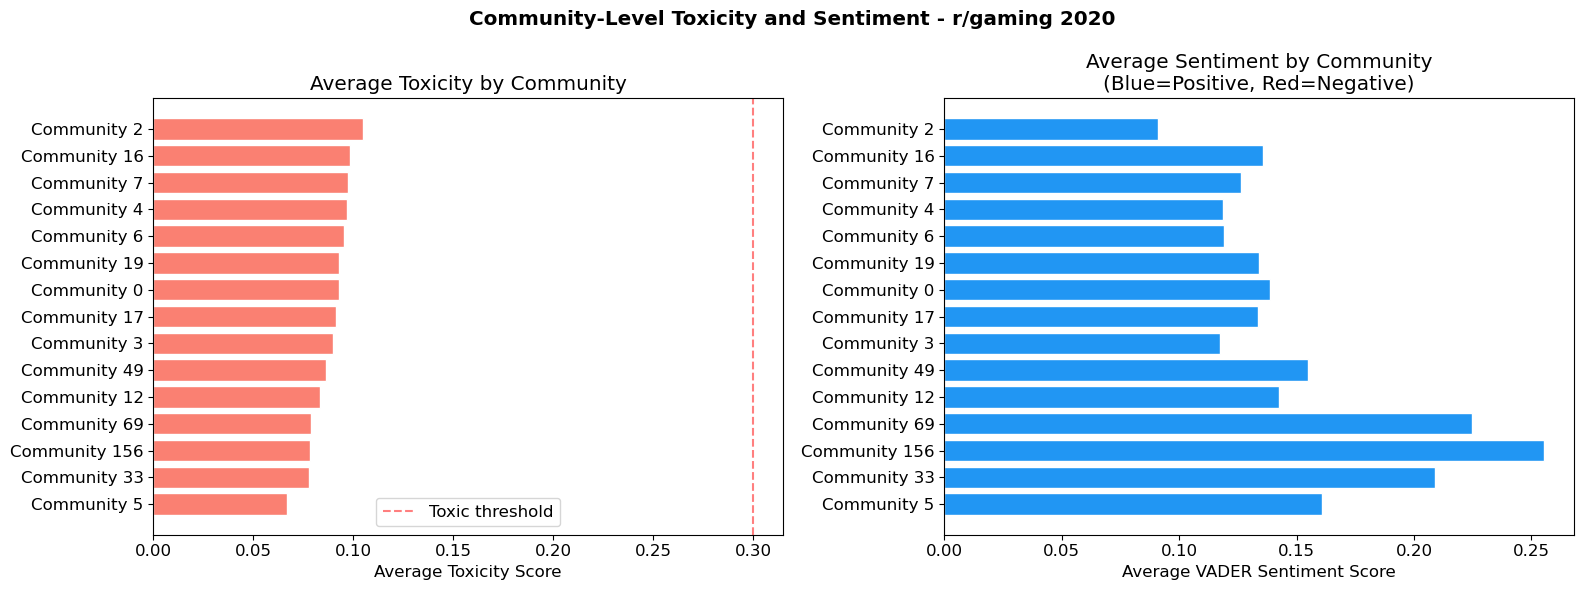

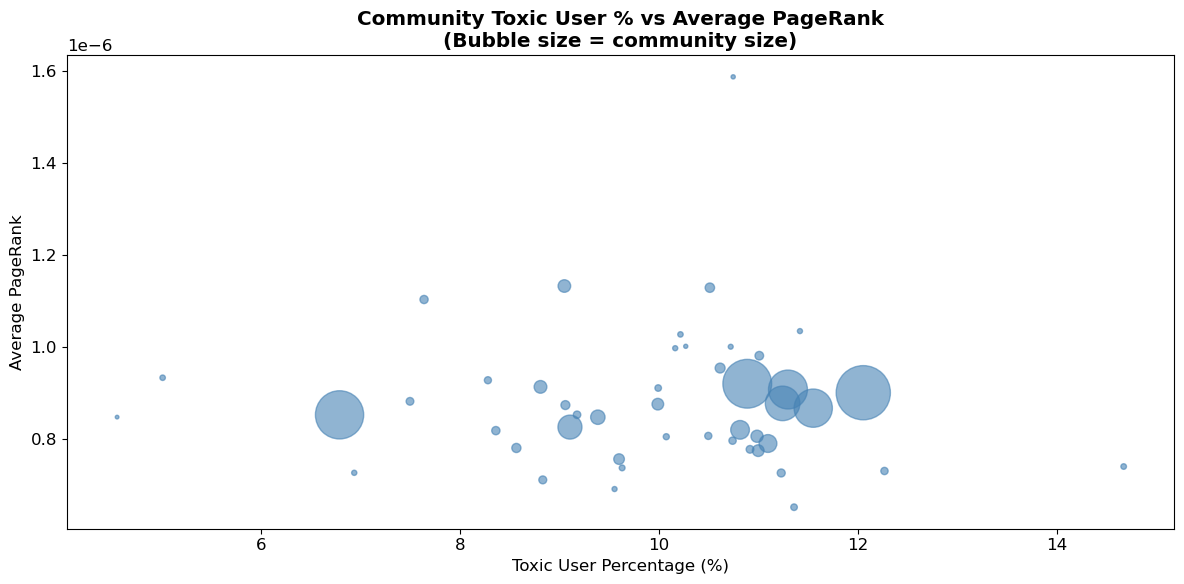

In [ ]:
#integrate community labels
community_df = pd.read_csv('data/large_community_users.csv')
print(f'Users with community labels: {len(community_df)}')
print(f'Number of communities: {community_df["community_id"].nunique()}')
community_df.head()

#merge community labels into centrality dataframe
centrality_community_df = centrality_df_known.merge(
    community_df, on='user_id', how='inner'
)

print(f'Users with both centrality and community data: {len(centrality_community_df)}')
print(f'Communities represented: {centrality_community_df["community_id"].nunique()}')
centrality_community_df.head()

#community-level centrality and toxicity summary
community_summary = centrality_community_df.groupby('community_id').agg(
    user_count=('user_id', 'count'),
    avg_toxicity=('avg_toxicity', 'mean'),
    avg_sentiment=('avg_sentiment', 'mean'),
    avg_pagerank=('pagerank', 'mean'),
    avg_degree=('degree_centrality', 'mean'),
    avg_betweenness=('betweenness_centrality', 'mean'),
    toxic_user_count=('is_toxic', 'sum'),
).reset_index()

#toxic user percentage per community
community_summary['toxic_pct'] = (
    community_summary['toxic_user_count'] / community_summary['user_count'] * 100
)

print('=== Community Summary (sorted by avg toxicity) ===')
print(community_summary.sort_values('avg_toxicity', ascending=False).to_string(index=False))

#toxicity and sentiment by community
#focus on top 15 communities by size for readability
top15_communities = community_summary.nlargest(15, 'user_count')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Community-Level Toxicity and Sentiment - r/gaming 2020', fontweight='bold')

#sort by toxicity for plots
top15_sorted = top15_communities.sort_values('avg_toxicity', ascending=True)

#toxicity by community
axes[0].barh(
    [f'Community {c}' for c in top15_sorted['community_id']],
    top15_sorted['avg_toxicity'],
    color='salmon', edgecolor='white'
)
axes[0].axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Toxic threshold')
axes[0].set_xlabel('Average Toxicity Score')
axes[0].set_title('Average Toxicity by Community')
axes[0].legend()

#sentiment by community
colours = ['#d62728' if s < 0 else '#2196F3' for s in top15_sorted['avg_sentiment']]
axes[1].barh(
    [f'Community {c}' for c in top15_sorted['community_id']],
    top15_sorted['avg_sentiment'],
    color=colours, edgecolor='white'
)
axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Average VADER Sentiment Score')
axes[1].set_title('Average Sentiment by Community\n(Blue=Positive, Red=Negative)')

plt.tight_layout()
plt.savefig('data/community_toxicity_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

#entrality of toxic users across communities
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    community_summary['toxic_pct'],
    community_summary['avg_pagerank'],
    s=community_summary['user_count'] / 100,
    alpha=0.6,
    color='steelblue'
)

ax.set_xlabel('Toxic User Percentage (%)')
ax.set_ylabel('Average PageRank')
ax.set_title('Community Toxic User % vs Average PageRank\n(Bubble size = community size)', 
             fontweight='bold')

plt.tight_layout()
plt.savefig('data/community_toxic_pct_vs_pagerank.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import networkx as nx

#load saved files
centrality_df_known = pd.read_csv('data/centrality_results.csv')
community_df = pd.read_csv('data/large_community_users.csv')  
#replace with the new filename your teammate gave you

print(f'Centrality users: {len(centrality_df_known):,}')
print(f'Community users: {len(community_df):,}')
print(f'Communities: {community_df["community_id"].nunique()}')

#check overlap
overlap = community_df['user_id'].isin(centrality_df_known['user_id'])
print(f'Matching users: {overlap.sum():,} ({overlap.mean()*100:.1f}%)')

#merge
centrality_community_df = centrality_df_known.merge(
    community_df, on='user_id', how='inner'
)
print(f'Merged shape: {centrality_community_df.shape}')
print(f'Communities represented: {centrality_community_df["community_id"].nunique()}')

#load graph
G = nx.read_graphml('data/gaming_reply_network.graphml')
print(f'Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

#community-level summary
community_summary = centrality_community_df.groupby('community_id').agg(
    user_count=('user_id', 'count'),
    avg_toxicity=('avg_toxicity', 'mean'),
    avg_sentiment=('avg_sentiment', 'mean'),
    avg_pagerank=('pagerank', 'mean'),
    avg_degree=('degree_centrality', 'mean'),
    avg_betweenness=('betweenness_centrality', 'mean'),
    toxic_user_count=('is_toxic', 'sum'),
).reset_index()

community_summary['toxic_pct'] = (
    community_summary['toxic_user_count'] / community_summary['user_count'] * 100
)

print('=== Community Summary (sorted by avg toxicity) ===')
print(community_summary.sort_values('avg_toxicity', ascending=False).to_string(index=False))

#within-community centrality (top user by PageRank per community)
community_centrality = []

for comm_id in centrality_community_df['community_id'].unique():
    members = centrality_community_df[
        centrality_community_df['community_id'] == comm_id
    ]['user_id'].tolist()
    
    if len(members) < 10:
        continue
    
    subgraph = G.subgraph(members)
    pr = nx.pagerank(subgraph, weight='weight')
    
    top_user = max(pr, key=pr.get)
    top_toxicity = G.nodes[top_user].get('avg_toxicity', None)
    top_sentiment = G.nodes[top_user].get('avg_sentiment', None)
    
    community_centrality.append({
        'community_id': comm_id,
        'top_user': top_user,
        'top_user_toxicity': top_toxicity,
        'top_user_sentiment': top_sentiment,
        'community_size': len(members)
    })

comm_centrality_df = pd.DataFrame(community_centrality)
print(comm_centrality_df.sort_values('top_user_toxicity', ascending=False).to_string(index=False))



Centrality users: 819,324
Community users: 879,627
Communities: 47
Matching users: 810,816 (92.2%)
Merged shape: (810816, 11)
Communities represented: 47
Graph loaded: 890,089 nodes, 2,872,306 edges
=== Community Summary (sorted by avg toxicity) ===
 community_id  user_count  avg_toxicity  avg_sentiment  avg_pagerank  avg_degree  avg_betweenness  toxic_user_count  toxic_pct
           75        1636      0.126677       0.162772  7.406027e-07    0.000004     2.547757e-07               240  14.669927
           25        2772      0.106396       0.173824  7.308948e-07    0.000003     3.337106e-07               340  12.265512
          216        2263      0.105993       0.223097  6.522196e-07    0.000003     9.701490e-09               257  11.356606
            2      152466      0.104744       0.091069  9.009955e-07    0.000006     2.578298e-07             18376  12.052523
           16       75995      0.098164       0.135886  8.674638e-07    0.000005     1.911429e-07              8777

In [ ]:
#get true community sizes from the CSV
true_sizes = community_df.groupby('community_id').size().reset_index(name='true_user_count')

#get toxicity/sentiment stats from the merged data
comm_stats = centrality_community_df.groupby('community_id').agg(
    avg_toxicity=('avg_toxicity', 'mean'),
    avg_sentiment=('avg_sentiment', 'mean'),
    toxic_user_count=('is_toxic', 'sum'),
    matched_users=('user_id', 'count')
).reset_index()

#merge true sizes with stats
community_summary_fixed = true_sizes.merge(comm_stats, on='community_id', how='left')
community_summary_fixed['toxic_pct'] = (
    community_summary_fixed['toxic_user_count'] / 
    community_summary_fixed['matched_users'] * 100
)

print('=== Fixed Community Summary (sorted by true size) ===')
print(community_summary_fixed.sort_values('true_user_count', ascending=False).head(15).to_string(index=False))

=== Fixed Community Summary (sorted by true size) ===
 community_id  true_user_count  avg_toxicity  avg_sentiment  toxic_user_count  matched_users  toxic_pct
            5           161525      0.067069       0.160714              8191         120669   6.787990
            2           156915      0.104744       0.091069             18376         152466  12.052523
            6           128177      0.095396       0.119270             13428         123347  10.886361
            7            81282      0.097435       0.126213              8885          78660  11.295449
           16            78265      0.098164       0.135886              8777          75995  11.549444
            4            64514      0.097054       0.118632              6967          61976  11.241448
           12            34985      0.083572       0.142390              2722          29899   9.103983
           17            18826      0.091435       0.133686              1961          18134  10.813941
          

In [ ]:
#most and least toxic communities (minimum 1000 users)
filtered = community_summary_fixed[community_summary_fixed['true_user_count'] >= 1000]

most_toxic = filtered.nlargest(3, 'avg_toxicity')
least_toxic = filtered.nsmallest(3, 'avg_toxicity')

print('\n=== Top 3 Most Toxic Communities (min 1000 users) ===')
print(most_toxic[['community_id', 'true_user_count', 'avg_toxicity', 'avg_sentiment', 'toxic_pct']].to_string(index=False))

print('\n=== Top 3 Least Toxic Communities (min 1000 users) ===')
print(least_toxic[['community_id', 'true_user_count', 'avg_toxicity', 'avg_sentiment', 'toxic_pct']].to_string(index=False))


=== Top 3 Most Toxic Communities (min 1000 users) ===
 community_id  true_user_count  avg_toxicity  avg_sentiment  toxic_pct
           75             1725      0.126677       0.162772  14.669927
           25             2884      0.106396       0.173824  12.265512
          216             2333      0.105993       0.223097  11.356606

=== Top 3 Least Toxic Communities (min 1000 users) ===
 community_id  true_user_count  avg_toxicity  avg_sentiment  toxic_pct
           29             1655      0.042714       0.134609   5.009634
          375             1444      0.061255       0.119717   6.935598
          287             3259      0.063226       0.318360   7.495961


In [17]:
#most and least negative sentiment communities (min 1000 users)
print('=== Top 3 Most Negative Sentiment Communities (min 1000 users) ===')
most_negative = filtered.nsmallest(3, 'avg_sentiment')
print(most_negative[['community_id', 'true_user_count', 'avg_toxicity', 'avg_sentiment', 'toxic_pct']].to_string(index=False))

print('\n=== Top 3 Most Positive Sentiment Communities (min 1000 users) ===')
most_positive = filtered.nlargest(3, 'avg_sentiment')
print(most_positive[['community_id', 'true_user_count', 'avg_toxicity', 'avg_sentiment', 'toxic_pct']].to_string(index=False))

=== Top 3 Most Negative Sentiment Communities (min 1000 users) ===
 community_id  true_user_count  avg_toxicity  avg_sentiment  toxic_pct
          141             2704      0.073544       0.044161   8.279283
           22             1437      0.085163       0.070240  10.162003
            2           156915      0.104744       0.091069  12.052523

=== Top 3 Most Positive Sentiment Communities (min 1000 users) ===
 community_id  true_user_count  avg_toxicity  avg_sentiment  toxic_pct
          287             3259      0.063226       0.318360   7.495961
          156             8602      0.078149       0.255361   8.807797
           32             3611      0.067176       0.227761   7.637300


In [12]:
#testing toxicity-negative sentiment correlation

centrality_df_known = pd.read_csv('data/centrality_results.csv')
print(f'Loaded {len(centrality_df_known):,} users')

correlation = centrality_df_known['avg_toxicity'].corr(centrality_df_known['avg_sentiment'])
print(f'\nPearson correlation (toxicity vs sentiment): {correlation:.4f}')

spearman_corr, spearman_p = stats.spearmanr(
    centrality_df_known['avg_toxicity'], 
    centrality_df_known['avg_sentiment']
)
print(f'Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}')

print('\n=== Average sentiment by toxicity classification ===')
print(centrality_df_known.groupby('is_toxic')['avg_sentiment'].describe())

centrality_df_known['is_negative'] = centrality_df_known['avg_sentiment'] < -0.3
print(f'\nNegative sentiment users (avg sentiment < -0.3): {centrality_df_known["is_negative"].sum():,}')
print(f'Percentage: {centrality_df_known["is_negative"].mean()*100:.1f}%')


cross_tab = pd.crosstab(
    centrality_df_known['is_toxic'],
    centrality_df_known['is_negative'],
    normalize='index'
) * 100
print('\n=== % negative sentiment within toxic vs non-toxic users ===')
print(cross_tab.round(1))


import scipy.stats as stats


correlation = centrality_df_known['avg_toxicity'].corr(centrality_df_known['avg_sentiment'])
print(f'Pearson correlation (toxicity vs sentiment): {correlation:.4f}')


spearman_corr, spearman_p = stats.spearmanr(
    centrality_df_known['avg_toxicity'], 
    centrality_df_known['avg_sentiment']
)
print(f'Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}')


print('\n=== Average sentiment by toxicity classification ===')
print(centrality_df_known.groupby('is_toxic')['avg_sentiment'].describe())


centrality_df_known['is_negative'] = centrality_df_known['avg_sentiment'] < -0.3
print(f'\nNegative sentiment users (avg sentiment < -0.3): {centrality_df_known["is_negative"].sum():,}')
print(f'Percentage: {centrality_df_known["is_negative"].mean()*100:.1f}%')


cross_tab = pd.crosstab(
    centrality_df_known['is_toxic'], 
    centrality_df_known['is_negative'],
    normalize='index'  # shows percentages within each toxic/non-toxic group
) * 100
print('\n=== % negative sentiment within toxic vs non-toxic users ===')
print(cross_tab.round(1))

Loaded 819,324 users

Pearson correlation (toxicity vs sentiment): -0.2765


NameError: name 'stats' is not defined

In [14]:
print('=== Out-degree: toxic vs non-toxic ===')
print(centrality_df_known.groupby('is_toxic')[['out_degree_centrality']].mean())

print('\n=== Correlation: out-degree vs toxicity ===')
print(f"Pearson: {centrality_df_known['out_degree_centrality'].corr(centrality_df_known['avg_toxicity']):.4f}")

=== Out-degree: toxic vs non-toxic ===
          out_degree_centrality
is_toxic                       
False                  0.000004
True                   0.000002

=== Correlation: out-degree vs toxicity ===
Pearson: 0.0061


## 7. Export Results

In [ ]:
#export centrality results to CSV
centrality_df_known.to_csv('data/centrality_results.csv', index=False)
print('Exported: data/centrality_results.csv')

#export graph as GraphML (compatible with Gephi if needed for visualisation)
#GraphML doesn't support boolean attributes, convert is_toxic to int
G_export = G.copy()
for node in G_export.nodes():
    if 'is_toxic' in G_export.nodes[node]:
        G_export.nodes[node]['is_toxic'] = int(G_export.nodes[node]['is_toxic'])

nx.write_graphml(G_export, 'data/gaming_reply_network.graphml')
print('Exported: data/gaming_reply_network.graphml (open in Gephi for advanced visualisation)')

print('Exports complete')


Exported: data/centrality_results.csv
Exported: data/gaming_reply_network.graphml (open in Gephi for advanced visualisation)
